In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import math
import os
from scipy import linalg
from torch.utils.data import DataLoader, TensorDataset, Subset
from scipy import linalg
import math

Task 0: Setup and dataset sanity

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.15MB/s]


Dataset sizes: train=60000, test=10000
Batches per epoch: 469



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/t


--- Sanity Checks ---
Tensor shape : torch.Size([128, 1, 28, 28])
Tensor dtype : torch.float32
Min value    : -1.0000
Max value    : 1.0000
Mean value   : -0.4682
All sanity checks passed ✓
Saved: reference_real_grid.png


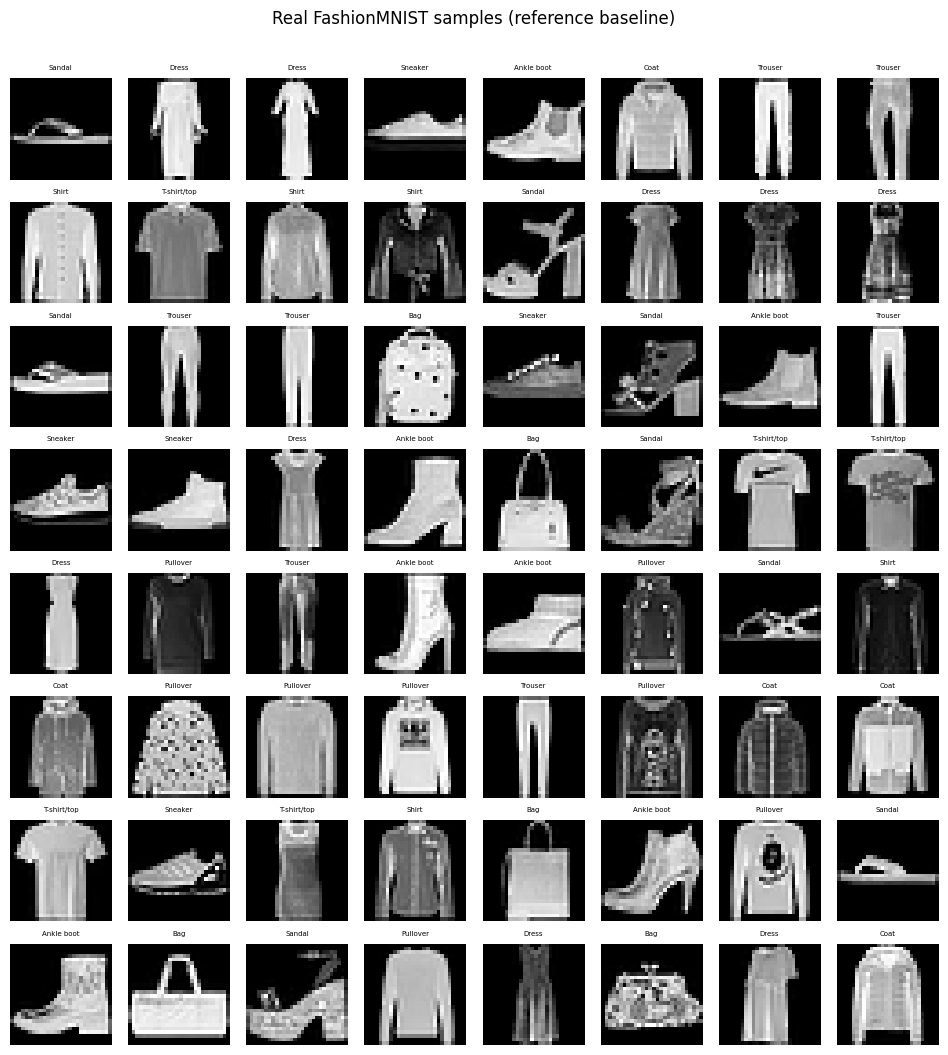

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),                        # (1, 28, 28), values in [0, 1]
    transforms.Normalize(mean=(0.5,), std=(0.5,)) # rescale to [−1, 1]
])

BATCH_SIZE = 128

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True,  download=True, transform=transform
)
test_dataset  = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"\nDataset sizes: train={len(train_dataset)}, test={len(test_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")


sample_batch, sample_labels = next(iter(train_loader))

print("\n--- Sanity Checks ---")
print(f"Tensor shape : {sample_batch.shape}")   # Expected: (128, 1, 28, 28)
print(f"Tensor dtype : {sample_batch.dtype}")   # Expected: torch.float32
print(f"Min value    : {sample_batch.min():.4f}")  # Expected: ≈ −1.0
print(f"Max value    : {sample_batch.max():.4f}")  # Expected: ≈ +1.0
print(f"Mean value   : {sample_batch.mean():.4f}") # Expected: ≈ 0.0 (roughly)

assert sample_batch.dtype == torch.float32,      "dtype must be float32"
assert sample_batch.min() >= -1.05,              "min out of range"
assert sample_batch.max() <=  1.05,              "max out of range"
assert sample_batch.shape[1:] == (1, 28, 28),   "wrong spatial shape"
print("All sanity checks passed ✓")


CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot"
]


def show_image_grid(images, labels=None, title="", save_path=None, nrow=8):
    """
    images : (N, 1, H, W) tensor in [−1, 1]
    Displays (and optionally saves) a grid of images.
    """
    # Denormalise: [−1, 1] → [0, 1]
    images = (images.clamp(-1, 1) + 1) / 2.0  # now in [0, 1]

    n = min(len(images), nrow * nrow)
    images = images[:n]

    ncols = nrow
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.2, nrows * 1.3))
    axes = axes.flatten()

    for idx in range(len(axes)):
        ax = axes[idx]
        if idx < n:
            img = images[idx].squeeze().numpy()  # (28, 28)
            ax.imshow(img, cmap="gray", vmin=0, vmax=1)
            if labels is not None:
                ax.set_title(CLASS_NAMES[labels[idx].item()], fontsize=5)
        ax.axis("off")

    fig.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

# Save reference grid of 64 real images
show_image_grid(
    sample_batch[:64],
    labels=sample_labels[:64],
    title="Real FashionMNIST samples (reference baseline)",
    save_path="reference_real_grid.png"
)


Task 1: Schedules and forward process

Schedule precomputed.
  alpha_bar[0]   = 0.9999  (should be ≈ 1.0, barely noised)
  alpha_bar[499] = 0.0786 (halfway, moderate noise)
  alpha_bar[999] = 0.0000  (should be ≈ 0.0, pure noise)
  SNR[0]         = 9997.34
  SNR[999]       = 0.000040


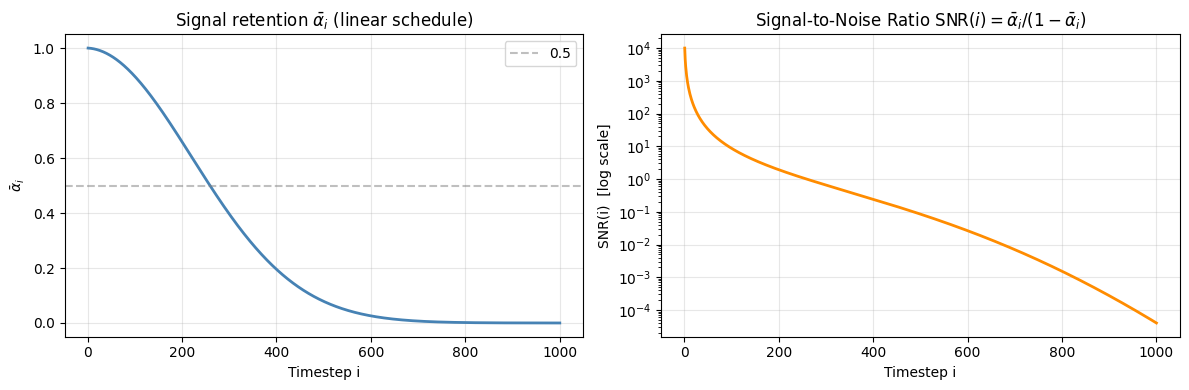

Saved: schedule_plots.png


In [ ]:
def make_beta_schedule(L=1000, schedule_type="linear",
                       beta_min=1e-4, beta_max=0.02):
    """
    Returns a 1-D tensor of shape (L,) containing {beta_i}_{i=1}^{L}.

    Args:
        L            : number of diffusion timesteps
        schedule_type: "linear" (default) or "cosine"
        beta_min     : smallest noise variance (at i=1)
        beta_max     : largest  noise variance (at i=L)

    Returns:
        betas : FloatTensor of shape (L,), values in (0, 1)
    """
    if schedule_type == "linear":
        # Linearly spaced from beta_min to beta_max
        # torch.linspace(a, b, L) gives L evenly-spaced values in [a, b]
        betas = torch.linspace(beta_min, beta_max, L)

    elif schedule_type == "cosine":
        # Cosine schedule (Nichol & Dhariwal 2021) — smoother decay of alpha_bar
        # alpha_bar(t) = f(t)/f(0),  f(t) = cos((t/T + s)/(1+s) * pi/2)^2
        # s=0.008 offset prevents beta_0 from being too small
        s = 0.008
        steps = torch.arange(L + 1, dtype=torch.float32)
        f = torch.cos(((steps / L) + s) / (1 + s) * torch.pi / 2) ** 2
        alpha_bar_cos = f / f[0]
        # Derive betas from alpha_bar: beta_i = 1 - alpha_bar_i/alpha_bar_{i-1}
        betas = 1.0 - (alpha_bar_cos[1:] / alpha_bar_cos[:-1])
        betas = betas.clamp(0.0001, 0.9999)  # safety clamp

    else:
        raise ValueError(f"Unknown schedule type: {schedule_type}")

    assert betas.shape == (L,), "betas must have length L"
    assert (betas > 0).all() and (betas < 1).all(), "betas must be in (0,1)"
    return betas


def precompute_schedule(betas):
    """
    Given betas (L,), returns a dict of all precomputed diffusion tensors.
    All tensors are moved to CPU here; index them on device during training.
    """
    L = len(betas)

    alphas          = 1.0 - betas                          # (L,)
    alpha_bar       = torch.cumprod(alphas, dim=0)         # (L,)  cumulative product

    # alpha_bar_{i-1}: needed for posterior formulas (Task 2)
    # We prepend alpha_bar_0 = 1.0 (no noise before the chain starts)
    alpha_bar_prev  = torch.cat([torch.tensor([1.0]), alpha_bar[:-1]])  # (L,)

    sqrt_alpha_bar       = torch.sqrt(alpha_bar)           # (L,)
    sqrt_one_minus_ab    = torch.sqrt(1.0 - alpha_bar)     # (L,)
    recip_sqrt_alpha     = 1.0 / torch.sqrt(alphas)        # (L,)  = 1/sqrt(alpha_i)
    SNR                  = alpha_bar / (1.0 - alpha_bar)   # (L,)

    return {
        "betas"              : betas,
        "alphas"             : alphas,
        "alpha_bar"          : alpha_bar,
        "alpha_bar_prev"     : alpha_bar_prev,
        "sqrt_alpha_bar"     : sqrt_alpha_bar,
        "sqrt_one_minus_ab"  : sqrt_one_minus_ab,
        "recip_sqrt_alpha"   : recip_sqrt_alpha,
        "SNR"                : SNR,
        "L"                  : L,
    }
def q_sample(x0, i, schedule, eps=None):

    if eps is None:
        eps = torch.randn_like(x0)  # N(0, I), same shape as x0

    # Extract scalars for this timestep (move to same device as x0)
    sqrt_ab     = schedule["sqrt_alpha_bar"][i].to(x0.device)
    sqrt_one_m  = schedule["sqrt_one_minus_ab"][i].to(x0.device)

    # Reshape scalars for broadcasting: (1,1,1,1) so they multiply (B,C,H,W)
    sqrt_ab    = sqrt_ab.view(1, 1, 1, 1)
    sqrt_one_m = sqrt_one_m.view(1, 1, 1, 1)

    x_i = sqrt_ab * x0 + sqrt_one_m * eps
    return x_i, eps


def sample_timesteps(batch_size, L, device):

    return torch.randint(0, L, (batch_size,), device=device)

L        = 1000
schedule = precompute_schedule(make_beta_schedule(L, "linear", 1e-4, 0.02))

print("Schedule precomputed.")
print(f"  alpha_bar[0]   = {schedule['alpha_bar'][0]:.4f}  (should be ≈ 1.0, barely noised)")
print(f"  alpha_bar[499] = {schedule['alpha_bar'][499]:.4f} (halfway, moderate noise)")
print(f"  alpha_bar[999] = {schedule['alpha_bar'][999]:.4f}  (should be ≈ 0.0, pure noise)")
print(f"  SNR[0]         = {schedule['SNR'][0]:.2f}")
print(f"  SNR[999]       = {schedule['SNR'][999]:.6f}")


def plot_schedule(schedule):
    L   = schedule["L"]
    ts  = np.arange(1, L + 1)  # display as 1-indexed for readability

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # --- Plot 1: alpha_bar_i ---
    axes[0].plot(ts, schedule["alpha_bar"].numpy(), color="steelblue", lw=2)
    axes[0].set_xlabel("Timestep i")
    axes[0].set_ylabel(r"$\bar{\alpha}_i$")
    axes[0].set_title(r"Signal retention $\bar{\alpha}_i$ (linear schedule)")
    axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="0.5")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Plot 2: SNR(i) on log scale ---
    snr = schedule["SNR"].numpy()
    axes[1].semilogy(ts, snr, color="darkorange", lw=2)
    axes[1].set_xlabel("Timestep i")
    axes[1].set_ylabel("SNR(i)  [log scale]")
    axes[1].set_title(r"Signal-to-Noise Ratio SNR$(i) = \bar{\alpha}_i / (1-\bar{\alpha}_i)$")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("schedule_plots.png", dpi=150)
    plt.show()
    print("Saved: schedule_plots.png")

plot_schedule(schedule)


def plot_forward_trajectory(x0_single, schedule, timesteps_to_show=None):
    """
    Visualise the forward noising process for a single image x0.
    x0_single: (1, 1, 28, 28) tensor in [−1, 1]
    """
    if timesteps_to_show is None:
        timesteps_to_show = [0, 100, 250, 500, 750, 999]

    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(2.5 * len(timesteps_to_show), 3))

    for ax, t_idx in zip(axes, timesteps_to_show):
        if t_idx == 0:
            img = x0_single
        else:
            img, _ = q_sample(x0_single, t_idx, schedule)
        img_display = (img.clamp(-1, 1) + 1) / 2.0  # → [0,1] for display
        ax.imshow(img_display.squeeze().cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"i={t_idx+1}\nSNR={schedule['SNR'][t_idx]:.3f}", fontsize=9)
        ax.axis("off")

    fig.suptitle("Forward noising trajectory  q(x_i | x_0)", fontsize=12)
    plt.tight_layout()
    plt.savefig("forward_trajectory.png", dpi=150)
    plt.show()
    print("Saved: forward_trajectory.png")


In [ ]:
def verify_forward_marginal(x0_single, schedule, t_idx=499, n_samples=2000):
    """
    Empirically verify E[x_i] and Var[x_i] match eq (2) for a given timestep.
    """
    sqrt_ab   = schedule["sqrt_alpha_bar"][t_idx].item()
    one_m_ab  = (1.0 - schedule["alpha_bar"][t_idx]).item()

    # Draw n_samples noisy versions of the same x0
    samples = []
    for _ in range(n_samples):
        xi, _ = q_sample(x0_single, t_idx, schedule)
        samples.append(xi)
    samples = torch.cat(samples, dim=0)  # (n_samples, 1, 28, 28)

    emp_mean = samples.mean(dim=0)                                  # (1, 28, 28)
    emp_var  = samples.var(dim=0).mean().item()                     # scalar

    expected_mean = sqrt_ab * x0_single.squeeze()
    mean_error    = (emp_mean.squeeze() - expected_mean).abs().mean().item()

    print(f"\n--- Empirical Verification at timestep i={t_idx+1} ---")
    print(f"  Expected mean coefficient : sqrt(alpha_bar) = {sqrt_ab:.4f}")
    print(f"  Mean absolute error       : {mean_error:.6f}  (should be ≈ 0)")
    print(f"  Expected variance         : 1 - alpha_bar   = {one_m_ab:.4f}")
    print(f"  Empirical variance        : {emp_var:.4f}  (should match above)")
    print(f"  Variance error            : {abs(emp_var - one_m_ab):.6f}  (should be ≈ 0)")

 Task 2: Posterior formulas and the reverse-step mechanics


--- Posterior Variance Verification ---
  All beta_tilde > 0         : True
  beta_tilde < beta (i>=2)   : True
  beta_tilde[1]  = 0.000055
  beta[1]        = 0.000120
  beta_tilde[500]= 0.010051
  beta[500]      = 0.010060


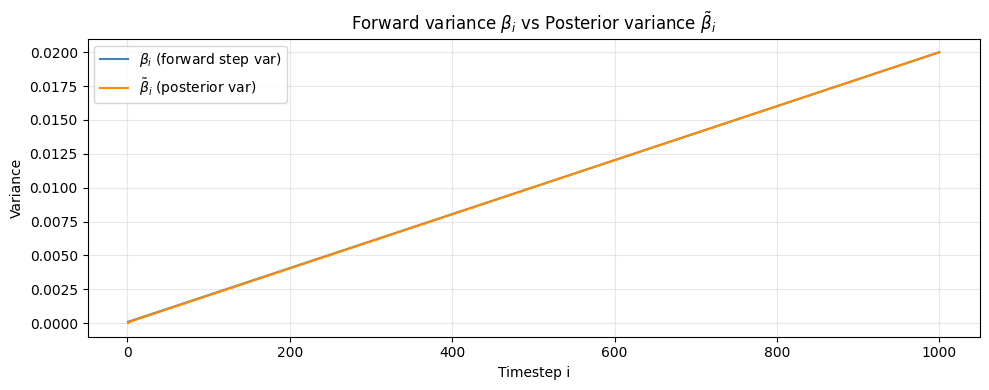

Saved: posterior_variance_comparison.png

--- Teacher Consistency Test (t=500) ---
  E[||x_i   - x_0||^2] = 1.3924
  E[||x_prev- x_0||^2] = 1.3901
  Denoising step reduces distance: True


In [ ]:
def compute_posterior_variance(schedule):
    """
    Precompute beta_tilde_i for all timesteps.
    Returns tensor of shape (L,).

    beta_tilde_i = (1 - alpha_bar_{i-1}) / (1 - alpha_bar_i) * beta_i

    Note: For i=1, alpha_bar_{i-1} = alpha_bar_0 = 1.0 (by convention),
    so beta_tilde_1 = 0. We clamp to a small value to avoid log(0) issues.
    """
    betas         = schedule["betas"]           # (L,)
    alpha_bar     = schedule["alpha_bar"]       # (L,)
    alpha_bar_prev= schedule["alpha_bar_prev"]  # (L,)  alpha_bar_{i-1}, starts with 1.0

    beta_tilde = (1.0 - alpha_bar_prev) / (1.0 - alpha_bar) * betas  # (L,)

    # At i=0 (paper's i=1): alpha_bar_prev=1.0, so beta_tilde[0] = 0.
    # Clamp for numerical safety (log, sqrt won't blow up).
    beta_tilde = beta_tilde.clamp(min=1e-20)

    return beta_tilde  # (L,)


def q_posterior_mean_var(x0, xi, i, schedule, beta_tilde):
    """
    Compute the true posterior mean and variance:
      mu_tilde_i(x_i, x_0)  and  beta_tilde_i

    Args:
        x0         : clean image, shape (B, C, H, W)
        xi         : noised image at step i, shape (B, C, H, W)
        i          : integer timestep index (0-indexed)
        schedule   : precomputed schedule dict
        beta_tilde : precomputed posterior variances, shape (L,)

    Returns:
        mu_tilde   : posterior mean, shape (B, C, H, W)
        var        : posterior variance scalar for step i
    """
    dev = x0.device

    # Extract scalars for timestep i
    alpha_bar_i    = schedule["alpha_bar"][i].to(dev)
    alpha_bar_prev = schedule["alpha_bar_prev"][i].to(dev)
    alpha_i        = schedule["alphas"][i].to(dev)
    beta_i         = schedule["betas"][i].to(dev)
    one_m_ab       = 1.0 - alpha_bar_i

    # Coefficients (eq 7)
    coeff_x0 = (torch.sqrt(alpha_bar_prev) * beta_i)                  / one_m_ab
    coeff_xi = (torch.sqrt(alpha_i) * (1.0 - alpha_bar_prev))         / one_m_ab

    # Reshape for broadcasting over (B, C, H, W)
    def bc(x): return x.view(1, 1, 1, 1)

    mu_tilde = bc(coeff_x0) * x0 + bc(coeff_xi) * xi   # (B, C, H, W)
    var      = beta_tilde[i].to(dev)

    return mu_tilde, var



def predict_x0_from_eps(xi, i, eps_hat, schedule):
    """
    Reconstruct estimated x_0 from predicted noise eps_hat.

    x0_hat = (x_i - sqrt(1 - alpha_bar_i) * eps_hat) / sqrt(alpha_bar_i)

    Args:
        xi      : noised image at step i, shape (B, C, H, W)
        i       : integer timestep index (0-indexed)
        eps_hat : predicted noise from network, shape (B, C, H, W)
        schedule: precomputed schedule dict

    Returns:
        x0_hat  : estimated clean image, shape (B, C, H, W)
    """
    dev = xi.device
    sqrt_ab     = schedule["sqrt_alpha_bar"][i].to(dev).view(1,1,1,1)
    sqrt_one_m  = schedule["sqrt_one_minus_ab"][i].to(dev).view(1,1,1,1)

    x0_hat = (xi - sqrt_one_m * eps_hat) / sqrt_ab
    return x0_hat


def p_mean_from_eps(xi, i, eps_hat, schedule):
    """
    Compute the reverse mean mu_theta(x_i, i) using predicted noise.

    mu_theta = (1/sqrt(alpha_i)) * [x_i - beta_i/sqrt(1-alpha_bar_i) * eps_hat]

    Args:
        xi      : noised image at step i, shape (B, C, H, W)
        i       : integer timestep index (0-indexed)
        eps_hat : predicted noise, shape (B, C, H, W)
        schedule: precomputed schedule dict

    Returns:
        mu_theta: reverse mean, shape (B, C, H, W)
    """
    dev = xi.device
    recip_sqrt_alpha = schedule["recip_sqrt_alpha"][i].to(dev).view(1,1,1,1)
    beta_i           = schedule["betas"][i].to(dev).view(1,1,1,1)
    sqrt_one_m_ab    = schedule["sqrt_one_minus_ab"][i].to(dev).view(1,1,1,1)

    mu_theta = recip_sqrt_alpha * (xi - (beta_i / sqrt_one_m_ab) * eps_hat)
    return mu_theta

def p_sample_step(xi, i, eps_hat, schedule, beta_tilde):
    """
    Perform one reverse diffusion step: x_i → x_{i-1}

    Args:
        xi         : current noisy image, shape (B, C, H, W)
        i          : current timestep index (0-indexed)
        eps_hat    : network's predicted noise, shape (B, C, H, W)
        schedule   : precomputed schedule dict
        beta_tilde : precomputed posterior variances, shape (L,)

    Returns:
        x_prev: denoised image one step back, shape (B, C, H, W)
    """
    mu = p_mean_from_eps(xi, i, eps_hat, schedule)   # eq (8)

    if i > 0:
        z = torch.randn_like(xi)                          # z ~ N(0, I)
        std = torch.sqrt(beta_tilde[i]).to(xi.device)
        x_prev = mu + std * z
    else:
        x_prev = mu   # no noise at final step

    return x_prev


def verify_posterior_variance(schedule, beta_tilde):
    """
    Verify two key properties of beta_tilde_i:
      1. beta_tilde_i > 0 for all i
      2. beta_tilde_i < beta_i  for i >= 2  (0-indexed: i >= 1)
    """
    betas = schedule["betas"]
    print("\n--- Posterior Variance Verification ---")
    print(f"  All beta_tilde > 0         : {(beta_tilde > 0).all().item()}")
    # Check beta_tilde < beta for i >= 1 (0-indexed), skip i=0
    ratio = (beta_tilde[1:] < betas[1:]).all().item()
    print(f"  beta_tilde < beta (i>=2)   : {ratio}")
    print(f"  beta_tilde[1]  = {beta_tilde[1].item():.6f}")
    print(f"  beta[1]        = {betas[1].item():.6f}")
    print(f"  beta_tilde[500]= {beta_tilde[500].item():.6f}")
    print(f"  beta[500]      = {betas[500].item():.6f}")


def verify_teacher_consistency(x0, schedule, beta_tilde, t_idx=499, n_trials=500):
    """
    Teacher consistency test:
      Sample (x0, eps, x_i) then draw x_{i-1} ~ q(x_{i-1}|x_i, x0).
      Verify that E[||x_{i-1} - x_0||^2] < E[||x_i - x_0||^2].
      i.e. each reverse step brings us CLOSER to x_0 on average.

    This is a sanity check that the posterior mean actually denoises.
    """
    dist_xi_list   = []
    dist_xprev_list = []

    for _ in range(n_trials):
        eps = torch.randn_like(x0)
        xi, _ = q_sample(x0, t_idx, schedule, eps=eps)

        mu_tilde, var = q_posterior_mean_var(x0, xi, t_idx, schedule, beta_tilde)
        z = torch.randn_like(x0)
        x_prev = mu_tilde + torch.sqrt(var) * z

        dist_xi   = (xi   - x0).pow(2).mean().item()
        dist_xprev= (x_prev - x0).pow(2).mean().item()
        dist_xi_list.append(dist_xi)
        dist_xprev_list.append(dist_xprev)

    mean_dist_xi    = np.mean(dist_xi_list)
    mean_dist_xprev = np.mean(dist_xprev_list)

    print(f"\n--- Teacher Consistency Test (t={t_idx+1}) ---")
    print(f"  E[||x_i   - x_0||^2] = {mean_dist_xi:.4f}")
    print(f"  E[||x_prev- x_0||^2] = {mean_dist_xprev:.4f}")
    print(f"  Denoising step reduces distance: {mean_dist_xprev < mean_dist_xi}")


def plot_beta_comparison(schedule, beta_tilde):
    """Plot beta_i vs beta_tilde_i to visually confirm beta_tilde < beta."""
    L  = schedule["L"]
    ts = np.arange(1, L + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(ts, schedule["betas"].numpy(),  label=r"$\beta_i$ (forward step var)", color="steelblue")
    plt.plot(ts, beta_tilde.numpy(), label=r"$\tilde{\beta}_i$ (posterior var)", color="darkorange")
    plt.xlabel("Timestep i")
    plt.ylabel("Variance")
    plt.title(r"Forward variance $\beta_i$ vs Posterior variance $\tilde{\beta}_i$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("posterior_variance_comparison.png", dpi=150)
    plt.show()
    print("Saved: posterior_variance_comparison.png")


# =============================================================================
# 2.7  RUN ALL VERIFICATIONS
# =============================================================================

# Compute beta_tilde (add this to your global schedule setup)
beta_tilde = compute_posterior_variance(schedule)

# Verification 1: variance properties
verify_posterior_variance(schedule, beta_tilde)

# Verification 2: plot beta vs beta_tilde
plot_beta_comparison(schedule, beta_tilde)

# Verification 3: teacher consistency
# Use a real image from train_loader in your full notebook:
#   x0_single = next(iter(train_loader))[0][:1].to(device)
x0_single = torch.randn(1, 1, 28, 28)  # placeholder
verify_teacher_consistency(x0_single, schedule, beta_tilde, t_idx=499)

Task 3: Build ϵθ(xi
, i) with timestep conditioning

In [ ]:
class SinusoidalTimestepEmbedding(nn.Module):
    """
    Sinusoidal positional embedding for diffusion timesteps.
    Maps integer timestep i → vector of shape (B, dim).
    """
    def __init__(self, dim):
        """
        Args:
            dim: embedding dimension (must be even)
        """
        super().__init__()
        assert dim % 2 == 0, "Embedding dim must be even"
        self.dim = dim

    def forward(self, timesteps):
        """
        Args:
            timesteps: LongTensor of shape (B,), values in {0,...,L-1}
        Returns:
            emb: FloatTensor of shape (B, dim)
        """
        device = timesteps.device
        half   = self.dim // 2

        # Frequencies: 1/10000^(2k/d) for k = 0,...,half-1
        freqs  = torch.exp(
            -math.log(10000) * torch.arange(half, device=device) / (half - 1)
        )  # (half,)

        # Outer product: timestep × frequency
        args   = timesteps[:, None].float() * freqs[None, :]  # (B, half)

        # Concatenate sin and cos
        emb    = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, dim)
        return emb
class ResidualBlock(nn.Module):
    """
    Residual block with timestep embedding injection.

    Structure:
      x → GroupNorm → SiLU → Conv2d → (+timestep_emb) → GroupNorm → SiLU → Conv2d
        → (+skip)
    """
    def __init__(self, in_channels, out_channels, time_emb_dim, num_groups=8):
        """
        Args:
            in_channels  : input channel count
            out_channels : output channel count
            time_emb_dim : dimension of the timestep embedding vector
            num_groups   : number of groups for GroupNorm (must divide channels)
        """
        super().__init__()

        # First conv block
        self.norm1 = nn.GroupNorm(num_groups=num_groups, num_channels=in_channels)
        self.act1  = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        # Timestep embedding projection → out_channels (for bias injection)
        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        # Second conv block
        self.norm2 = nn.GroupNorm(num_groups=num_groups, num_channels=out_channels)
        self.act2  = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Skip connection: 1x1 conv if channel dims differ, else identity
        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, time_emb):
        """
        Args:
            x        : feature map, shape (B, in_channels, H, W)
            time_emb : timestep embedding, shape (B, time_emb_dim)
        Returns:
            out      : shape (B, out_channels, H, W)
        """
        h = self.conv1(self.act1(self.norm1(x)))

        # Project timestep embedding and inject as spatial bias
        # time_proj output: (B, out_channels) → reshape to (B, out_channels, 1, 1)
        t = self.time_proj(time_emb)[:, :, None, None]
        h = h + t   # broadcast over H, W

        h = self.conv2(self.act2(self.norm2(h)))

        return h + self.skip(x)   # residual connection
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Stride-2 conv: halves H and W
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # 2x nearest-neighbour upsample, then refine with conv
        self.up   = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        return self.conv(self.up(x))

class UNet(nn.Module):
    """
    Small U-Net for FashionMNIST DDPM.
    Input : (B, 1, 28, 28) noised image + (B,) timestep indices
    Output: (B, 1, 28, 28) predicted noise eps_hat
    """
    def __init__(
        self,
        in_channels   = 1,       # grayscale
        base_channels = 32,      # channel multiplier base
        channel_mults = (1,2,4), # → 32, 64, 128 channels
        time_emb_dim  = 128,     # sinusoidal embedding dimension
        time_mlp_dim  = 512,     # MLP hidden/output dimension fed to blocks
        num_groups    = 8,       # GroupNorm groups (must divide all channel counts)
    ):
        super().__init__()

        # --- Timestep embedding pipeline ---
        # Sinusoidal embedding → MLP → time_mlp_dim
        self.time_embed = nn.Sequential(
            SinusoidalTimestepEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_mlp_dim),
            nn.SiLU(),
            nn.Linear(time_mlp_dim, time_mlp_dim),
        )

        # Channel sizes at each resolution level
        channels = [base_channels * m for m in channel_mults]  # [32, 64, 128]

        # --- Initial projection: 1 → 32 channels ---
        self.input_proj = nn.Conv2d(in_channels, channels[0], kernel_size=3, padding=1)

        # --- Encoder ---
        # Level 0: 28×28, 32ch
        self.enc0 = ResidualBlock(channels[0], channels[0], time_mlp_dim, num_groups)
        self.down0 = Downsample(channels[0])   # → 14×14

        # Level 1: 14×14, 32→64ch
        self.enc1 = ResidualBlock(channels[0], channels[1], time_mlp_dim, num_groups)
        self.down1 = Downsample(channels[1])   # → 7×7

        # Level 2: 7×7, 64→128ch
        self.enc2 = ResidualBlock(channels[1], channels[2], time_mlp_dim, num_groups)

        # --- Bottleneck: 7×7, 128ch ---
        self.bottleneck = ResidualBlock(channels[2], channels[2], time_mlp_dim, num_groups)

        # --- Decoder ---
        # Level 2 up: concat with enc2 skip → 256ch → 64ch, then upsample → 14×14
        self.dec2 = ResidualBlock(channels[2] * 2, channels[1], time_mlp_dim, num_groups)
        self.up2  = Upsample(channels[1])

        # Level 1 up: concat with enc1 skip → 128ch → 32ch, then upsample → 28×28
        self.dec1 = ResidualBlock(channels[1] * 2, channels[0], time_mlp_dim, num_groups)
        self.up1  = Upsample(channels[0])

        # Level 0 up: concat with enc0 skip → 64ch → 32ch
        self.dec0 = ResidualBlock(channels[0] * 2, channels[0], time_mlp_dim, num_groups)

        # --- Output projection: 32ch → 1ch (predicted noise) ---
        self.output_proj = nn.Sequential(
            nn.GroupNorm(num_groups=num_groups, num_channels=channels[0]),
            nn.SiLU(),
            nn.Conv2d(channels[0], in_channels, kernel_size=3, padding=1)
        )

    def forward(self, x, timesteps):
        """
        Args:
            x         : noised image, shape (B, 1, 28, 28)
            timesteps : integer timesteps, shape (B,)
        Returns:
            eps_hat   : predicted noise, shape (B, 1, 28, 28)
        """
        # 1. Timestep embedding: (B,) → (B, time_mlp_dim)
        t = self.time_embed(timesteps)

        # 2. Initial projection: (B,1,28,28) → (B,32,28,28)
        x = self.input_proj(x)

        # 3. Encoder — save skip connections
        s0 = self.enc0(x, t)            # (B, 32, 28, 28)
        x  = self.down0(s0)             # (B, 32, 14, 14)

        s1 = self.enc1(x, t)            # (B, 64, 14, 14)
        x  = self.down1(s1)             # (B, 64,  7,  7)

        s2 = self.enc2(x, t)            # (B,128,  7,  7)

        # 4. Bottleneck
        x  = self.bottleneck(s2, t)     # (B,128,  7,  7)

        # 5. Decoder — concatenate skips along channel dim
        x  = torch.cat([x, s2], dim=1) # (B,256,  7,  7)
        x  = self.dec2(x, t)           # (B, 64,  7,  7)
        x  = self.up2(x)               # (B, 64, 14, 14)

        x  = torch.cat([x, s1], dim=1) # (B,128, 14, 14)
        x  = self.dec1(x, t)           # (B, 32, 14, 14)
        x  = self.up1(x)               # (B, 32, 28, 28)

        x  = torch.cat([x, s0], dim=1) # (B, 64, 28, 28)
        x  = self.dec0(x, t)           # (B, 32, 28, 28)

        # 6. Output projection → predicted noise
        eps_hat = self.output_proj(x)   # (B,  1, 28, 28)

        return eps_hat



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"U-Net instantiated on {device}")
print(f"Total parameters: {total_params:,}  ({total_params/1e6:.2f}M)")

# --- Shape check: forward pass with dummy inputs ---
B = 4
dummy_x = torch.randn(B, 1, 28, 28).to(device)    # (B, C, H, W)
dummy_t = torch.randint(0, 1000, (B,)).to(device)  # (B,)

with torch.no_grad():
    dummy_out = model(dummy_x, dummy_t)

print(f"\nShape check:")
print(f"  Input  : {dummy_x.shape}")
print(f"  Output : {dummy_out.shape}")   # Must be (B, 1, 28, 28)
assert dummy_out.shape == dummy_x.shape, "Output shape must match input shape!"
print("Shape check passed ✓")

# --- Verify timestep embedding is actually used (not silently dropped) ---
# If the embedding is unused, different timesteps should give IDENTICAL outputs
# for the same x. We check they differ.
dummy_t2 = torch.zeros(B, dtype=torch.long).to(device)   # all t=0
dummy_t3 = torch.full((B,), 999, dtype=torch.long).to(device)  # all t=999

with torch.no_grad():
    out_t0   = model(dummy_x, dummy_t2)
    out_t999 = model(dummy_x, dummy_t3)

diff = (out_t0 - out_t999).abs().mean().item()
print(f"\nTimestep conditioning check:")
print(f"  Mean |out(t=0) - out(t=999)| = {diff:.6f}  (should be >> 0)")
assert diff > 1e-4, "Timestep embedding appears unused — check injection!"
print("Timestep conditioning check passed ✓")

U-Net instantiated on cuda
Total parameters: 1,552,257  (1.55M)

Shape check:
  Input  : torch.Size([4, 1, 28, 28])
  Output : torch.Size([4, 1, 28, 28])
Shape check passed ✓

Timestep conditioning check:
  Mean |out(t=0) - out(t=999)| = 0.038837  (should be >> 0)
Timestep conditioning check passed ✓


Task 4: Train DDPM with Lsimple

In [ ]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("samples",     exist_ok=True)

# =============================================================================
# 4.1  DATALOADERS
# =============================================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
def compute_loss(model, x0, schedule):
    """
    Compute L_simple for a batch of clean images x0.

    Args:
        model    : UNet, eps_theta(x_i, i)
        x0       : clean images, shape (B, 1, 28, 28), in [-1,1]
        schedule : precomputed schedule dict

    Returns:
        loss : scalar MSE loss
    """
    B = x0.shape[0]

    # Step 2: sample random timesteps for each image in the batch
    timesteps = sample_timesteps(B, schedule["L"], device=x0.device)  # (B,)

    # Step 3: sample noise
    eps = torch.randn_like(x0)  # (B, 1, 28, 28)

    # Step 4: compute noisy images x_i using closed-form marginal (eq 2)
    # We need to handle per-sample timesteps — each image gets a different t
    sqrt_ab    = schedule["sqrt_alpha_bar"][timesteps].to(x0.device)      # (B,)
    sqrt_one_m = schedule["sqrt_one_minus_ab"][timesteps].to(x0.device)   # (B,)

    # Reshape for broadcasting: (B,) → (B, 1, 1, 1)
    sqrt_ab    = sqrt_ab.view(B, 1, 1, 1)
    sqrt_one_m = sqrt_one_m.view(B, 1, 1, 1)

    x_noisy = sqrt_ab * x0 + sqrt_one_m * eps  # (B, 1, 28, 28)

    # Step 5: predict noise
    eps_hat = model(x_noisy, timesteps)         # (B, 1, 28, 28)

    # Step 6: MSE loss between true noise and predicted noise
    loss = F.mse_loss(eps, eps_hat)             # scalar
    return loss

import torch.nn.functional as F


def save_sample_grid(images, path, title=""):
    """
    images: (N, 1, 28, 28) tensor in [-1,1]
    Saves a grid to disk.
    """
    images = (images.clamp(-1, 1) + 1) / 2.0  # → [0,1]
    n   = min(len(images), 64)
    images = images[:n].cpu()
    nrow = 8
    nrows = math.ceil(n / nrow)

    fig, axes = plt.subplots(nrows, nrow, figsize=(nrow * 1.2, nrows * 1.2))
    axes = axes.flatten()
    for idx in range(len(axes)):
        ax = axes[idx]
        if idx < n:
            ax.imshow(images[idx].squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.savefig(path, dpi=120, bbox_inches="tight")
    plt.close()

@torch.no_grad()
def sample(model, schedule, beta_tilde, n_samples=64, device=device):
    """
    Ancestral DDPM sampler: x_L ~ N(0,I) → x_0.
    Full version with trajectory saving is in Task 5.
    """
    model.eval()
    L  = schedule["L"]

    # Start from pure Gaussian noise
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    for i in reversed(range(L)):               # i = L-1, L-2, ..., 0
        t = torch.full((n_samples,), i, dtype=torch.long, device=device)
        eps_hat = model(x, t)
        x = p_sample_step(x, i, eps_hat, schedule, beta_tilde)

    model.train()
    return x


# =============================================================================
# 4.5  TRAINING LOOP
#
#  Key logging to implement (assignment requirement):
#   - training loss per step
#   - gradient norm (detects exploding gradients early)
#   - periodic sample grids (visual quality check)
#
#  Training budget: >= 100k gradient steps (assignment baseline).
#  With batch=128 and 60k training images → ~469 steps/epoch → ~213 epochs.
# =============================================================================

def train(
    model,
    schedule,
    beta_tilde,
    train_loader,
    n_steps       = 100_000,   # total gradient steps
    lr            = 2e-4,      # Adam learning rate (assignment baseline)
    log_every     = 200,       # print loss every N steps
    sample_every  = 5_000,     # save sample grid every N steps
    save_every    = 20_000,    # save checkpoint every N steps
    grad_clip     = 1.0,       # max gradient norm (set None to disable)
):
    """
    Main DDPM training loop.

    Returns:
        loss_history     : list of (step, loss) tuples
        grad_norm_history: list of (step, grad_norm) tuples
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0)

    # Learning rate warmup (optional but stabilises early training)
    # Linear warmup for first 1000 steps
    warmup_steps = 1000
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lambda step: min(1.0, step / warmup_steps)
    )

    loss_history      = []
    grad_norm_history = []
    step = 0

    model.train()
    print(f"Starting training: {n_steps} steps, lr={lr}, batch={BATCH_SIZE}")
    print(f"Logging every {log_every} | Sampling every {sample_every} | "
          f"Saving every {save_every}")

    # Infinite dataloader loop
    data_iter = iter(train_loader)

    while step < n_steps:
        # --- Get next batch (reset iterator if exhausted) ---
        try:
            x0, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x0, _ = next(data_iter)

        x0 = x0.to(device)  # (B, 1, 28, 28)

        # --- Forward pass + loss ---
        optimizer.zero_grad()
        loss = compute_loss(model, x0, schedule)

        # --- Backward pass ---
        loss.backward()

        # --- Gradient clipping (prevents explosions, especially early) ---
        if grad_clip is not None:
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        else:
            grad_norm = sum(p.grad.norm().item() ** 2
                            for p in model.parameters()
                            if p.grad is not None) ** 0.5

        # --- Optimizer + LR scheduler step ---
        optimizer.step()
        scheduler.step()

        # --- Logging ---
        loss_val     = loss.item()
        grad_norm_val= grad_norm.item() if hasattr(grad_norm, 'item') else grad_norm

        loss_history.append((step, loss_val))
        grad_norm_history.append((step, grad_norm_val))

        if step % log_every == 0:
            print(f"Step {step:6d}/{n_steps} | "
                  f"Loss: {loss_val:.4f} | "
                  f"GradNorm: {grad_norm_val:.3f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

        # --- Periodic sample grid ---
        if step % sample_every == 0 and step > 0:
            print(f"  Generating samples at step {step}...")
            samples = sample(model, schedule, beta_tilde, n_samples=64, device=device)
            save_sample_grid(
                samples,
                path=f"samples/samples_step{step:06d}.png",
                title=f"DDPM samples — step {step}"
            )
            print(f"  Saved: samples/samples_step{step:06d}.png")

        # --- Checkpoint ---
        if step % save_every == 0 and step > 0:
            ckpt_path = f"checkpoints/ddpm_step{step:06d}.pt"
            torch.save({
                "step"        : step,
                "model_state" : model.state_dict(),
                "optim_state" : optimizer.state_dict(),
                "loss"        : loss_val,
            }, ckpt_path)
            print(f"  Checkpoint saved: {ckpt_path}")

        step += 1

    print(f"\nTraining complete. Final loss: {loss_history[-1][1]:.4f}")
    return loss_history, grad_norm_history

In [ ]:
def plot_training_curves(loss_history, grad_norm_history):
    steps      = [s for s, _ in loss_history]
    losses     = [l for _, l in loss_history]
    gnorm_steps= [s for s, _ in grad_norm_history]
    gnorms     = [g for _, g in grad_norm_history]

    # Smooth loss with moving average for readability
    def smooth(vals, w=50):
        return np.convolve(vals, np.ones(w)/w, mode='valid')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Loss curve
    axes[0].plot(steps, losses, alpha=0.3, color="steelblue", lw=0.8, label="raw")
    if len(losses) > 50:
        axes[0].plot(steps[49:], smooth(losses), color="steelblue", lw=2, label="smoothed")
    axes[0].set_xlabel("Training step")
    axes[0].set_ylabel("L_simple (MSE)")
    axes[0].set_title("Training Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Gradient norm
    axes[1].plot(gnorm_steps, gnorms, alpha=0.4, color="darkorange", lw=0.8)
    if len(gnorms) > 50:
        axes[1].plot(gnorm_steps[49:], smooth(gnorms), color="darkorange", lw=2)
    axes[1].set_xlabel("Training step")
    axes[1].set_ylabel("Gradient norm")
    axes[1].set_title("Gradient Norm (clipped at 1.0)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Saved: training_curves.png")


# =============================================================================
# 4.7  SANITY CHECKS  (run BEFORE full training)
#
#  The assignment mandates these checks. If any fail, DO NOT proceed to
#  full training — there is a fundamental bug in your implementation.
# =============================================================================

def sanity_check_overfit(model, schedule, beta_tilde, n_images=256, n_steps=2000):
    """
    Sanity check 1: OVERFIT TEST
    Train on only 256 images. After ~2000 steps, samples should
    visibly resemble those 256 images.
    If they don't → bug in forward process, posterior, or timestep conditioning.
    """
    print("\n--- Sanity Check 1: Overfit Test (256 images) ---")

    # Tiny dataset
    tiny_dataset = Subset(train_dataset, indices=list(range(n_images)))
    tiny_loader  = DataLoader(tiny_dataset, batch_size=32, shuffle=True)

    # Temporarily train with high LR for fast overfitting
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    data_iter = iter(tiny_loader)

    for step in range(n_steps):
        try:
            x0, _ = next(data_iter)
        except StopIteration:
            data_iter = iter(tiny_loader)
            x0, _ = next(data_iter)

        x0 = x0.to(device)
        opt.zero_grad()
        loss = compute_loss(model, x0, schedule)
        loss.backward()
        opt.step()

        if step % 500 == 0:
            print(f"  Step {step}: loss = {loss.item():.4f}")

    # Sample and save
    samples = sample(model, schedule, beta_tilde, n_samples=32, device=device)
    save_sample_grid(samples, "sanity_overfit_samples.png", "Overfit test (256 imgs)")
    print("  Saved: sanity_overfit_samples.png")
    print("  → Inspect visually: samples should look like FashionMNIST items")


def sanity_check_one_step_posterior(x0, schedule, beta_tilde, t_idx=499, n_trials=1000):
    """
    Sanity check 2: ONE-STEP POSTERIOR CHECK
    Draw x_{i-1} ~ q(x_{i-1}|x_i, x_0) and verify:
      E[||x_{i-1} - x_0||^2] < E[||x_i - x_0||^2]
    Each true posterior step should reduce distance to x_0.
    """
    print(f"\n--- Sanity Check 2: One-Step Posterior (t={t_idx+1}) ---")

    dist_xi_list   = []
    dist_xprev_list= []

    for _ in range(n_trials):
        eps = torch.randn_like(x0)
        xi, _ = q_sample(x0, t_idx, schedule, eps=eps)

        mu_tilde, var = q_posterior_mean_var(x0, xi, t_idx, schedule, beta_tilde)
        z     = torch.randn_like(x0)
        x_prev= mu_tilde + torch.sqrt(var) * z

        dist_xi_list.append((xi    - x0).pow(2).mean().item())
        dist_xprev_list.append((x_prev - x0).pow(2).mean().item())

    mean_xi   = np.mean(dist_xi_list)
    mean_xprev= np.mean(dist_xprev_list)
    print(f"  E[||x_i    - x_0||^2] = {mean_xi:.4f}")
    print(f"  E[||x_prev - x_0||^2] = {mean_xprev:.4f}")
    print(f"  Posterior reduces distance: {mean_xprev < mean_xi}  ✓" if mean_xprev < mean_xi
          else "  WARNING: posterior does NOT reduce distance — check posterior formulas!")


def sanity_check_noise_correlation(model, schedule, n_batches=5):
    """
    Sanity check 3: NOISE PREDICTION CORRELATION
    For a fixed timestep, compute Pearson correlation between
    true ε and predicted ε̂ over a validation batch.
    A well-trained model should have high correlation (> 0.5 after early training).
    A random model will have ~0 correlation.
    """
    print("\n--- Sanity Check 3: Noise Prediction Correlation ---")
    model.eval()
    t_idx = 499  # fixed mid-range timestep

    all_eps, all_eps_hat = [], []
    data_iter = iter(test_loader)

    with torch.no_grad():
        for _ in range(n_batches):
            x0, _ = next(data_iter)
            x0 = x0.to(device)
            B  = x0.shape[0]

            eps = torch.randn_like(x0)
            sqrt_ab    = schedule["sqrt_alpha_bar"][t_idx].to(device).view(1,1,1,1)
            sqrt_one_m = schedule["sqrt_one_minus_ab"][t_idx].to(device).view(1,1,1,1)
            xi         = sqrt_ab * x0 + sqrt_one_m * eps

            t = torch.full((B,), t_idx, dtype=torch.long, device=device)
            eps_hat = model(xi, t)

            all_eps.append(eps.view(B, -1).cpu())
            all_eps_hat.append(eps_hat.view(B, -1).cpu())

    eps_flat     = torch.cat(all_eps,     dim=0).numpy()   # (N, D)
    eps_hat_flat = torch.cat(all_eps_hat, dim=0).numpy()   # (N, D)

    # Per-dimension correlation, then average
    corr = np.corrcoef(eps_flat.flatten(), eps_hat_flat.flatten())[0, 1]
    print(f"  Pearson corr(ε, ε̂) at t={t_idx+1}: {corr:.4f}")
    print(f"  (After ~100k steps, expect > 0.7 for FashionMNIST)")
    model.train()


def sanity_check_timestep_histogram(n_samples=10000):
    """
    Sanity check 4: TIMESTEP SAMPLING IS UNIFORM
    Verify sample_timesteps produces a flat histogram over {0,...,L-1}.
    """
    print("\n--- Sanity Check 4: Timestep Histogram ---")
    ts = sample_timesteps(n_samples, schedule["L"], device).cpu().numpy()
    counts, _ = np.histogram(ts, bins=10)
    expected  = n_samples / 10

    print(f"  Histogram over 10 bins (expected ≈ {expected:.0f} each):")
    for i, c in enumerate(counts):
        bar = "█" * int(c / expected * 10)
        print(f"  Bin {i}: {c:5d}  {bar}")

    deviation = np.abs(counts - expected).max() / expected
    print(f"  Max relative deviation: {deviation:.3f}  "
          f"{'✓ uniform' if deviation < 0.1 else 'WARNING: not uniform!'}")


Task 5: Implement the full ancestral DDPM sampler

=== Generating denoising trajectory ===


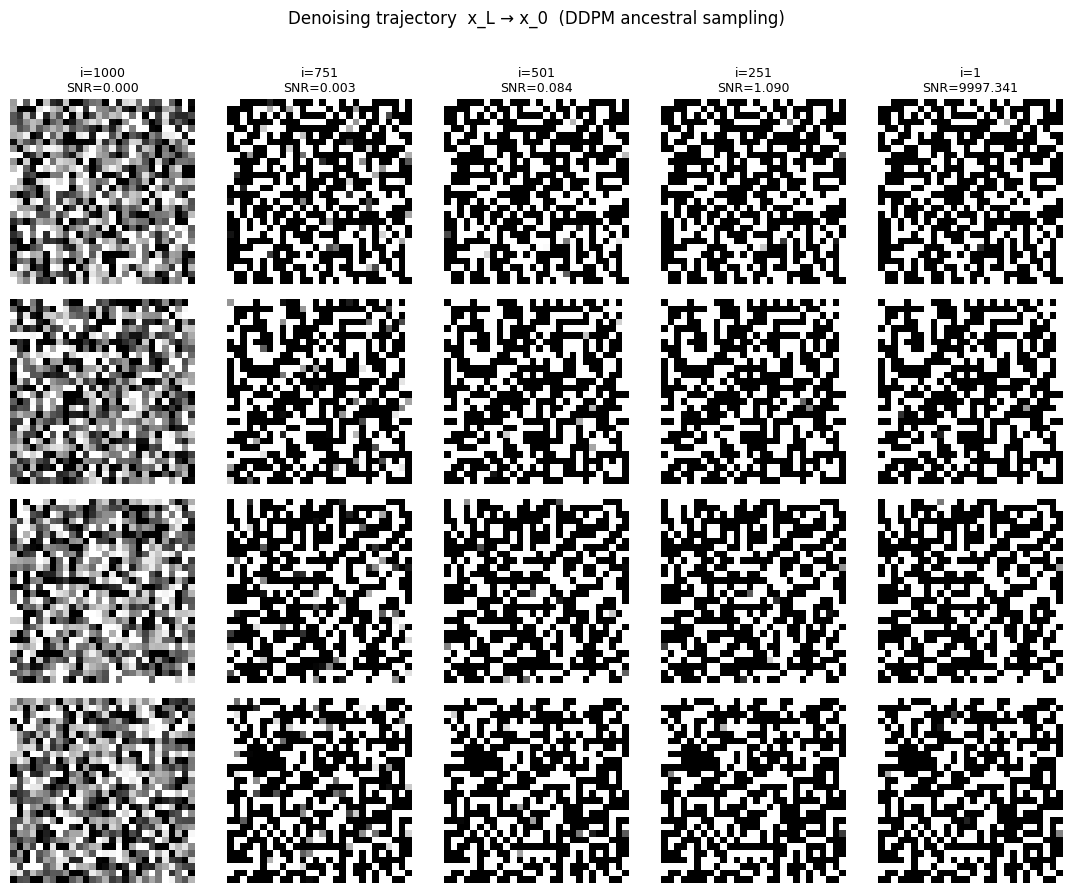

Saved: denoising_trajectory.png

=== Tracking sampling norms ===


RuntimeError: linalg.matrix_norm: dim must be a 2-tuple. Got 1 2 3

In [ ]:
@torch.no_grad()
def ancestral_sample(
    model,
    schedule,
    beta_tilde,
    n_samples         = 64,
    save_trajectory   = True,
    trajectory_steps  = None,   # which timesteps to snapshot
    device            = device,
):
    """
    Full ancestral DDPM sampler.

    Args:
        model            : trained UNet
        schedule         : precomputed schedule dict (from Task 1)
        beta_tilde       : posterior variances (from Task 2)
        n_samples        : number of images to generate
        save_trajectory  : if True, save intermediate x_i snapshots
        trajectory_steps : list of i values to snapshot
                           default: [L-1, 3L/4, L/2, L/4, 0]
        device           : torch device

    Returns:
        x0        : final generated images, shape (n_samples, 1, 28, 28)
        trajectory: dict {timestep: tensor (n_samples, 1, 28, 28)} or None
    """
    model.eval()
    L = schedule["L"]

    # Default trajectory checkpoints: L, 3L/4, L/2, L/4, final
    if trajectory_steps is None:
        trajectory_steps = sorted(set([
            L - 1,
            int(3 * L / 4),
            int(L / 2),
            int(L / 4),
            0
        ]), reverse=True)

    trajectory = {} if save_trajectory else None

    # --- Step 1: Sample x_L ~ N(0, I) ---
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    if save_trajectory and (L - 1) in trajectory_steps:
        trajectory[L - 1] = x.clone().cpu()

    # --- Step 2: Reverse chain x_L → x_0 ---
    for i in reversed(range(L)):      # i = L-1, L-2, ..., 1, 0

        # Timestep tensor for the whole batch
        t = torch.full((n_samples,), i, dtype=torch.long, device=device)

        # Network predicts noise
        eps_hat = model(x, t)          # (n_samples, 1, 28, 28)

        # Compute reverse mean µ_θ (eq 8)
        mu = p_mean_from_eps(x, i, eps_hat, schedule)

        if i > 0:
            # Stochastic reverse step: x_{i-1} = µ + √β̃_i * z
            z   = torch.randn_like(x)
            std = torch.sqrt(beta_tilde[i]).to(device)
            x   = mu + std * z
        else:
            # Final step: no noise — return mean directly
            x = mu

        # Save trajectory snapshot
        if save_trajectory and i in trajectory_steps:
            trajectory[i] = x.clone().cpu()

    model.train()
    return x.cpu(), trajectory

def plot_denoising_trajectory(trajectory, n_rows=4, save_path="denoising_trajectory.png"):
    """
    Visualise the denoising trajectory for n_rows samples.

    trajectory: dict {timestep_idx: (N, 1, 28, 28) tensor in [-1,1]}
    """
    timesteps_sorted = sorted(trajectory.keys(), reverse=True)
    n_cols = len(timesteps_sorted)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.2, n_rows * 2.2))

    for col, t_idx in enumerate(timesteps_sorted):
        imgs = trajectory[t_idx]             # (N, 1, 28, 28)
        imgs_disp = (imgs.clamp(-1, 1) + 1) / 2.0   # → [0,1]

        # Column title: show timestep and SNR
        snr_val = schedule["SNR"][t_idx].item() if t_idx < schedule["L"] else float("inf")
        label   = f"i={t_idx+1}\nSNR={snr_val:.3f}" if snr_val < 1e4 else f"i={t_idx+1}\n(noise)"

        for row in range(n_rows):
            ax = axes[row, col]
            ax.imshow(imgs_disp[row].squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
            ax.axis("off")
            if row == 0:
                ax.set_title(label, fontsize=9)

    # Row labels
    for row in range(n_rows):
        axes[row, 0].set_ylabel(f"Sample {row+1}", fontsize=8)

    fig.suptitle("Denoising trajectory  x_L → x_0  (DDPM ancestral sampling)",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")



@torch.no_grad()
def track_sampling_norms(
    model,
    schedule,
    beta_tilde,
    n_samples = 16,
    log_every = 100,
    device    = device,
):
    """
    Run the sampler while recording ||x_i||_2 at each timestep.
    Returns a list of (timestep, mean_norm) pairs.
    """
    model.eval()
    L = schedule["L"]
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    norm_history = [(L, x.norm(dim=(1,2,3)).mean().item())]

    for i in reversed(range(L)):
        t       = torch.full((n_samples,), i, dtype=torch.long, device=device)
        eps_hat = model(x, t)
        mu      = p_mean_from_eps(x, i, eps_hat, schedule)

        if i > 0:
            z = torch.randn_like(x)
            x = mu + torch.sqrt(beta_tilde[i]).to(device) * z
        else:
            x = mu

        if i % log_every == 0:
            norm_history.append((i, x.norm(dim=(1,2,3)).mean().item()))

    model.train()
    return norm_history


def plot_norm_trajectory(norm_history, save_path="sampling_norms.png"):
    steps = [L - s for s, _ in norm_history]   # convert to "steps taken"
    norms = [n for _, n in norm_history]

    # Theoretical starting norm: E[||x||] for x~N(0,I), shape (1,28,28)
    D = 28 * 28
    theoretical_start = math.sqrt(D)

    plt.figure(figsize=(9, 4))
    plt.plot(steps, norms, color="steelblue", lw=2, label="||x_i|| during sampling")
    plt.axhline(theoretical_start, color="gray", linestyle="--",
                label=f"E[||N(0,I)||] = √D ≈ {theoretical_start:.1f}")
    plt.xlabel("Sampling steps taken  (0 = start from x_L)")
    plt.ylabel("Mean L2 norm  ||x_i||")
    plt.title("Image norm during ancestral sampling (should not explode)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


def generate_final_grid(model, schedule, beta_tilde, n_samples=64,
                        save_path="final_sample_grid.png"):
    print(f"Generating {n_samples} samples...")
    samples, _ = ancestral_sample(
        model, schedule, beta_tilde,
        n_samples=n_samples,
        save_trajectory=False,
        device=device,
    )

    samples_disp = (samples.clamp(-1, 1) + 1) / 2.0   # → [0,1]
    nrow = 8
    nrows = math.ceil(n_samples / nrow)

    fig, axes = plt.subplots(nrows, nrow, figsize=(nrow * 1.4, nrows * 1.4))
    axes = axes.flatten()
    for idx in range(len(axes)):
        ax = axes[idx]
        if idx < n_samples:
            ax.imshow(samples_disp[idx].squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

    fig.suptitle(f"DDPM generated samples — FashionMNIST  (n={n_samples})", fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
    return samples


# --- 1. Generate trajectory for a fixed seed ---
print("=== Generating denoising trajectory ===")
torch.manual_seed(42)
_, trajectory = ancestral_sample(
    model, schedule, beta_tilde,
    n_samples        = 8,
    save_trajectory  = True,
    device           = device,
)
plot_denoising_trajectory(trajectory, n_rows=4,
                          save_path="denoising_trajectory.png")

# --- 2. Track norms to check for blow-ups ---
print("\n=== Tracking sampling norms ===")
norm_history = track_sampling_norms(model, schedule, beta_tilde,
                                    n_samples=16, device=device)
plot_norm_trajectory(norm_history)

# --- 3. Final 64-sample grid ---
print("\n=== Generating final sample grid ===")
final_samples = generate_final_grid(model, schedule, beta_tilde,
                                    n_samples=64,
                                    save_path="final_sample_grid.png")

=== Tracking sampling norms ===


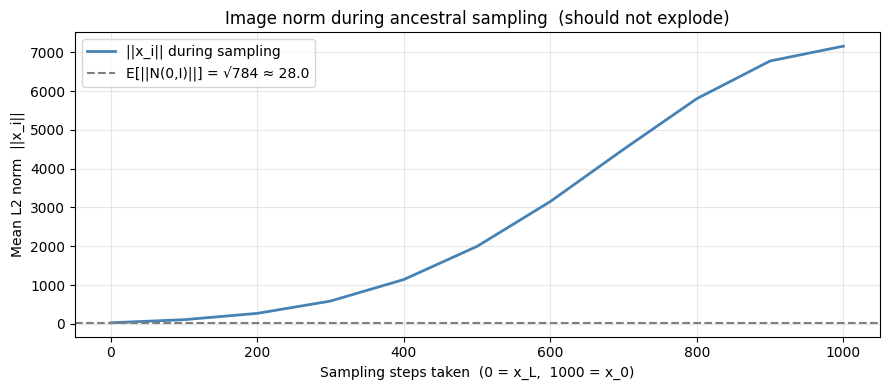

Saved: sampling_norms.png


In [ ]:
@torch.no_grad()
def track_sampling_norms(
    model,
    schedule,
    beta_tilde,
    n_samples = 16,
    log_every = 100,
    device    = device,
):
    """
    Run the sampler while recording mean L2 norm of x_i at each timestep.
    Returns a list of (timestep_index, mean_norm) pairs.
    """
    model.eval()
    L = schedule["L"]
    x = torch.randn(n_samples, 1, 28, 28, device=device)

    # Compute L2 norm per image: sqrt(sum of squared pixel values)
    # x shape: (B, 1, H, W)  →  norm shape: (B,)
    def batch_norm(t):
        return t.pow(2).sum(dim=(1, 2, 3)).sqrt().mean().item()

    norm_history = [(L - 1, batch_norm(x))]   # record starting norm at x_L

    for i in reversed(range(L)):
        t       = torch.full((n_samples,), i, dtype=torch.long, device=device)
        eps_hat = model(x, t)
        mu      = p_mean_from_eps(x, i, eps_hat, schedule)

        if i > 0:
            z = torch.randn_like(x)
            x = mu + torch.sqrt(beta_tilde[i]).to(device) * z
        else:
            x = mu

        if i % log_every == 0:
            norm_history.append((i, batch_norm(x)))

    model.train()
    return norm_history


def plot_norm_trajectory(norm_history, save_path="sampling_norms.png"):
    # x-axis: steps TAKEN (0 = just started from x_L, L = finished at x_0)
    L      = schedule["L"]
    steps  = [L - s for s, _ in norm_history]
    norms  = [n      for _, n in norm_history]

    # Theoretical L2 norm of a (1,28,28) sample from N(0,I) = sqrt(784) ≈ 28
    D = 28 * 28
    theoretical_start = math.sqrt(D)

    plt.figure(figsize=(9, 4))
    plt.plot(steps, norms, color="steelblue", lw=2, label="||x_i|| during sampling")
    plt.axhline(theoretical_start, color="gray", linestyle="--",
                label=f"E[||N(0,I)||] = √784 ≈ {theoretical_start:.1f}")
    plt.xlabel("Sampling steps taken  (0 = x_L,  1000 = x_0)")
    plt.ylabel("Mean L2 norm  ||x_i||")
    plt.title("Image norm during ancestral sampling  (should not explode)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


# --- Re-run diagnostics ---
print("=== Tracking sampling norms ===")
norm_history = track_sampling_norms(model, schedule, beta_tilde,
                                    n_samples=16, device=device)
plot_norm_trajectory(norm_history)

Task 6: Focused ablations + one DDPM-adjacent extension

Task 7: Evaluation and reporting

In [ ]:
class FeatureExtractorCNN(nn.Module):
    """
    Small CNN classifier for FashionMNIST.
    Used as fixed feature extractor ϕ(x) → R^128 for FID/KID computation.
    """
    def __init__(self, num_classes=10, emb_dim=128):
        super().__init__()
        self.emb_dim = emb_dim

        # Convolutional backbone
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # →14×14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # → 7×7
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(4),  # →4×4
        )

        # Embedding layer (this is ϕ(x))
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, emb_dim),
            nn.ReLU(),
        )

        # Classification head (used only during training)
        self.classifier = nn.Linear(emb_dim, num_classes)

    def forward(self, x, return_embedding=False):
        feat = self.features(x)
        emb  = self.embedding(feat)
        if return_embedding:
            return emb                          # ϕ(x) ∈ R^128
        return self.classifier(emb)


def train_feature_extractor(train_loader, test_loader,
                             n_epochs=10, lr=1e-3, save_path="feature_extractor.pt"):
    """
    Train the CNN classifier on real FashionMNIST training data.
    Save weights so ϕ is fixed across all evaluation runs.
    """
    if os.path.exists(save_path):
        print(f"Loading existing feature extractor from {save_path}")
        fe = FeatureExtractorCNN().to(device)
        fe.load_state_dict(torch.load(save_path, map_location=device))
        fe.eval()
        return fe

    print("Training feature extractor CNN...")
    fe  = FeatureExtractorCNN().to(device)
    opt = torch.optim.Adam(fe.parameters(), lr=lr)

    for epoch in range(n_epochs):
        fe.train()
        correct, total = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = fe(x)
            loss   = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()
            correct += (logits.argmax(1) == y).sum().item()
            total   += len(y)
        acc = correct / total
        print(f"  Epoch {epoch+1}/{n_epochs} | train acc: {acc:.3f}")

    # Test accuracy
    fe.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            correct += (fe(x).argmax(1) == y).sum().item()
            total   += len(y)
    print(f"  Test accuracy: {correct/total:.3f}")

    torch.save(fe.state_dict(), save_path)
    print(f"  Saved: {save_path}")
    return fe


# =============================================================================
# 7.2  EXTRACT EMBEDDINGS  ϕ(x) for a set of images
# =============================================================================

@torch.no_grad()
def extract_embeddings(images_tensor, feature_extractor, batch_size=256):
    """
    Extract ϕ(x) embeddings for all images.

    Args:
        images_tensor    : (N, 1, 28, 28) tensor in [-1,1]
        feature_extractor: trained FeatureExtractorCNN
        batch_size       : processing batch size

    Returns:
        embeddings: (N, emb_dim) numpy array
    """
    feature_extractor.eval()
    all_embs = []
    dataset  = TensorDataset(images_tensor)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    for (batch,) in loader:
        batch = batch.to(device)
        emb   = feature_extractor(batch, return_embedding=True)
        all_embs.append(emb.cpu().numpy())

    return np.concatenate(all_embs, axis=0)   # (N, 128)

def compute_fid(emb_gen, emb_real):
    """
    Compute FID between two sets of embeddings.

    Args:
        emb_gen  : (N, d) numpy array — generated image embeddings
        emb_real : (M, d) numpy array — real image embeddings

    Returns:
        fid : scalar float
    """
    mu_g, sigma_g = emb_gen.mean(0),  np.cov(emb_gen,  rowvar=False)
    mu_r, sigma_r = emb_real.mean(0), np.cov(emb_real, rowvar=False)

    diff = mu_g - mu_r

    # Matrix square root: (Σ_g @ Σ_r)^{1/2}
    # scipy.linalg.sqrtm computes the matrix square root
    covmean, _ = linalg.sqrtm(sigma_g @ sigma_r, disp=False)

    # Handle numerical issues: sqrtm can produce tiny imaginary parts
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma_g + sigma_r - 2.0 * covmean)
    return float(fid)

def polynomial_kernel(X, Y, degree=3, gamma=None, coef0=1.0):
    """Polynomial kernel: k(x,y) = (gamma * x·y + coef0)^degree"""
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    K = (gamma * (X @ Y.T) + coef0) ** degree
    return K


def compute_kid(emb_gen, emb_real, n_subsets=100, subset_size=1000):
    """
    Compute KID via subset MMD estimation (more stable than full MMD).

    Randomly samples pairs of subsets and averages MMD² estimates.
    This gives an unbiased, lower-variance estimate.

    Args:
        emb_gen      : (N, d) generated embeddings
        emb_real     : (M, d) real embeddings
        n_subsets    : number of random subsets to average over
        subset_size  : size of each subset

    Returns:
        kid_mean : mean KID across subsets
        kid_std  : std of KID across subsets
    """
    n_gen  = len(emb_gen)
    n_real = len(emb_real)
    ss     = min(subset_size, n_gen, n_real)

    mmds = []
    for _ in range(n_subsets):
        idx_g = np.random.choice(n_gen,  ss, replace=False)
        idx_r = np.random.choice(n_real, ss, replace=False)
        g     = emb_gen[idx_g].astype(np.float32)
        r     = emb_real[idx_r].astype(np.float32)

        # MMD² = E[k(g,g)] - 2*E[k(g,r)] + E[k(r,r)]
        Kgg = polynomial_kernel(g, g)
        Krr = polynomial_kernel(r, r)
        Kgr = polynomial_kernel(g, r)

        # Unbiased: exclude diagonal for same-set terms
        np.fill_diagonal(Kgg, 0)
        np.fill_diagonal(Krr, 0)
        mmd2 = (Kgg.sum() / (ss*(ss-1)) +
                Krr.sum() / (ss*(ss-1)) -
                2 * Kgr.mean())
        mmds.append(mmd2)

    return float(np.mean(mmds)), float(np.std(mmds))


@torch.no_grad()
def classifier_quality_diversity(generated_images, feature_extractor, batch_size=256):
    """
    Assess quality and diversity of generated images via classifier predictions.

    Args:
        generated_images : (N, 1, 28, 28) tensor in [-1,1]
        feature_extractor: trained FeatureExtractorCNN

    Returns:
        accuracy : fraction of generated images predicted with high confidence
        entropy  : entropy of predicted class distribution (higher = more diverse)
        class_counts: predicted class histogram (10 classes)
    """
    feature_extractor.eval()
    all_probs   = []
    all_preds   = []

    dataset = TensorDataset(generated_images)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    for (batch,) in loader:
        batch  = batch.to(device)
        logits = feature_extractor(batch)                    # (B, 10)
        probs  = F.softmax(logits, dim=-1).cpu().numpy()    # (B, 10)
        preds  = probs.argmax(axis=1)
        all_probs.append(probs)
        all_preds.append(preds)

    all_probs = np.concatenate(all_probs, axis=0)  # (N, 10)
    all_preds = np.concatenate(all_preds, axis=0)  # (N,)

    # Quality: mean max probability (how "confident" the classifier is)
    quality = all_probs.max(axis=1).mean()

    # Diversity: entropy of marginal class distribution
    class_dist = all_probs.mean(axis=0)             # average over samples
    class_dist = np.clip(class_dist, 1e-10, 1.0)
    entropy    = -np.sum(class_dist * np.log(class_dist))
    max_entropy = np.log(10)

    # Class prediction counts
    class_counts = np.bincount(all_preds, minlength=10)

    print(f"  Classifier confidence (quality) : {quality:.3f}")
    print(f"  Class entropy (diversity)       : {entropy:.3f} / {max_entropy:.3f}")
    print(f"  Class counts: {class_counts}")

    return quality, entropy, class_counts


def plot_class_distribution(class_counts, title="Generated class distribution",
                             save_path="class_distribution.png"):
    CLASS_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                   "Sandal",  "Shirt",   "Sneaker",  "Bag",   "Boot"]
    plt.figure(figsize=(10, 4))
    bars = plt.bar(CLASS_NAMES, class_counts, color="steelblue", edgecolor="white")
    expected = class_counts.sum() / 10
    plt.axhline(expected, color="tomato", linestyle="--", label=f"Uniform ({expected:.0f})")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")



def nearest_neighbour_check(generated_images, train_dataset,
                             feature_extractor, n_check=8,
                             save_path="nn_memorisation_check.png"):
    """
    For n_check generated images, find and display the nearest training image
    in both pixel space and feature space.
    """
    # Get a large subset of training images for comparison
    n_train_subset = 10_000
    train_imgs_list = []
    train_loader_seq = DataLoader(train_dataset, batch_size=512, shuffle=False)
    for x, _ in train_loader_seq:
        train_imgs_list.append(x)
        if sum(t.shape[0] for t in train_imgs_list) >= n_train_subset:
            break
    train_imgs = torch.cat(train_imgs_list, dim=0)[:n_train_subset]  # (N, 1, 28, 28)

    gen_subset = generated_images[:n_check]   # (n_check, 1, 28, 28)

    # --- Pixel-space nearest neighbours ---
    gen_flat   = gen_subset.view(n_check, -1)           # (n_check, 784)
    train_flat = train_imgs.view(n_train_subset, -1)    # (N, 784)

    # L2 distance matrix: (n_check, N)
    dists_pixel = torch.cdist(gen_flat, train_flat)     # (n_check, N)
    nn_pixel_idx = dists_pixel.argmin(dim=1)            # (n_check,)

    # --- Feature-space nearest neighbours ---
    print("  Extracting embeddings for NN check...")
    emb_gen   = extract_embeddings(gen_subset,  feature_extractor)  # (n_check, 128)
    emb_train = extract_embeddings(train_imgs,  feature_extractor)  # (N, 128)

    emb_gen_t   = torch.from_numpy(emb_gen)
    emb_train_t = torch.from_numpy(emb_train)
    dists_feat  = torch.cdist(emb_gen_t, emb_train_t)  # (n_check, N)
    nn_feat_idx = dists_feat.argmin(dim=1)              # (n_check,)

    # --- Plot: 3 columns × n_check rows: (generated, NN-pixel, NN-feature) ---
    fig, axes = plt.subplots(n_check, 3, figsize=(6, n_check * 1.8))

    col_titles = ["Generated", "Nearest (pixel)", "Nearest (feature)"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10)

    def show(ax, img_tensor):
        img = (img_tensor.clamp(-1,1) + 1) / 2.0
        ax.imshow(img.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

    for row in range(n_check):
        show(axes[row, 0], gen_subset[row])
        show(axes[row, 1], train_imgs[nn_pixel_idx[row]])
        show(axes[row, 2], train_imgs[nn_feat_idx[row]])

    fig.suptitle("Nearest-neighbour memorisation check\n"
                 "(similar = memorisation risk; diverse = healthy generalisation)",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def kl_gaussians(mu1, var1, mu2, var2):
    """
    KL divergence KL(N(mu1, var1*I) || N(mu2, var2*I)) in d dimensions.
    mu1, mu2 : (B, D) or broadcastable
    var1, var2: scalars

    Returns scalar mean over batch.
    """
    d    = mu1.shape[1] if mu1.dim() > 1 else mu1.numel()
    diff = (mu1 - mu2).pow(2).sum(dim=-1)   # (B,)
    kl   = 0.5 * (d * (var1/var2 - 1 - torch.log(torch.tensor(var1/var2)))
                  + diff / var2)
    return kl.mean()


@torch.no_grad()
def estimate_bpd(model, schedule, beta_tilde, data_loader,
                 n_batches=20, obs_var=0.1):
    """
    Estimate bits-per-dimension using the ELBO decomposition (eq 11).

    Args:
        model      : trained UNet
        schedule   : precomputed schedule dict
        beta_tilde : posterior variances
        data_loader: test set loader
        n_batches  : number of test batches to average over
        obs_var    : variance of Gaussian observation model p_θ(x0|x1)

    Returns:
        bpd : float, bits per dimension
    """
    model.eval()
    L   = schedule["L"]
    D   = 28 * 28    # number of dimensions

    total_elbo = 0.0
    n_samples  = 0

    data_iter = iter(data_loader)

    for batch_idx in range(n_batches):
        try:
            x0, _ = next(data_iter)
        except StopIteration:
            break
        x0 = x0.to(device)
        B  = x0.shape[0]

        elbo_batch = torch.zeros(B, device=device)

        # --- L_prior = KL(q(xL|x0) || N(0,I)) ---
        # q(xL|x0) = N(sqrt(ab_L)*x0, (1-ab_L)*I)
        # KL(N(µ, σ²I) || N(0,I)) = 0.5*(D*σ² - D - D*log(σ²) + ||µ||²)
        ab_L      = schedule["alpha_bar"][-1].to(device)
        mu_L      = (ab_L.sqrt() * x0).view(B, -1)
        var_L     = (1.0 - ab_L).item()
        kl_prior  = 0.5 * (D * var_L - D - D * math.log(var_L)
                           + mu_L.pow(2).sum(dim=-1))
        elbo_batch += kl_prior

        # --- L_diffusion = Σ_{i=2}^{L} KL terms ---
        # Sample a subset of timesteps for Monte Carlo estimation
        # (computing all L-1 terms exactly is expensive)
        sample_steps = list(range(1, L))   # i=1,...,L-1 (0-indexed)
        # For speed, use every 10th step and rescale
        stride       = 10
        sampled_steps = sample_steps[::stride]
        scale_factor  = len(sample_steps) / len(sampled_steps)

        for i in sampled_steps:
            # Sample x_i ~ q(x_i|x_0)
            eps     = torch.randn_like(x0)
            sqrt_ab = schedule["sqrt_alpha_bar"][i].to(device).view(1,1,1,1)
            sqrt_om = schedule["sqrt_one_minus_ab"][i].to(device).view(1,1,1,1)
            xi      = sqrt_ab * x0 + sqrt_om * eps

            # True posterior mean µ̃_i and variance β̃_i
            mu_tilde, var_tilde = q_posterior_mean_var(x0, xi, i, schedule, beta_tilde)
            mu_tilde_flat = mu_tilde.view(B, -1)
            var_p = var_tilde.item()

            # Model mean µ_θ using predicted eps
            t_tensor = torch.full((B,), i, dtype=torch.long, device=device)
            eps_hat  = model(xi, t_tensor)
            mu_theta = p_mean_from_eps(xi, i, eps_hat, schedule)
            mu_theta_flat = mu_theta.view(B, -1)

            # KL(q(x_{i-1}|x_i,x0) || p_θ(x_{i-1}|x_i))
            # Both are Gaussian with SAME variance β̃_i (our variance convention)
            # So KL = ||µ̃ - µ_θ||² / (2*β̃_i)
            kl_diff = (mu_tilde_flat - mu_theta_flat).pow(2).sum(dim=-1) / (2.0 * var_p)
            elbo_batch += kl_diff * scale_factor

        # --- L_recon = -log p_θ(x0|x1) under Gaussian model ---
        # p_θ(x0|x1) = N(µ_θ(x1,1), obs_var*I)
        # -log p_θ = D/2*log(2π*obs_var) + ||x0 - µ_θ||²/(2*obs_var)
        eps_r  = torch.randn_like(x0)
        sqrt_a = schedule["sqrt_alpha_bar"][0].to(device).view(1,1,1,1)
        sqrt_o = schedule["sqrt_one_minus_ab"][0].to(device).view(1,1,1,1)
        x1     = sqrt_a * x0 + sqrt_o * eps_r
        t0     = torch.zeros(B, dtype=torch.long, device=device)
        mu_t0  = p_mean_from_eps(x1, 0, model(x1, t0), schedule)
        recon  = (0.5 * D * math.log(2 * math.pi * obs_var)
                  + (x0 - mu_t0).pow(2).view(B,-1).sum(dim=-1) / (2.0 * obs_var))
        elbo_batch += recon

        total_elbo += elbo_batch.sum().item()
        n_samples  += B

        if batch_idx % 5 == 0:
            running_bpd = (total_elbo / n_samples) / (D * math.log(2))
            print(f"  Batch {batch_idx+1}/{n_batches} | running bpd: {running_bpd:.3f}")

    mean_elbo = total_elbo / n_samples
    bpd       = mean_elbo / (D * math.log(2))

    print(f"\n  Final ELBO estimate : {mean_elbo:.2f}")
    print(f"  Bits-per-dimension  : {bpd:.3f} bpd")
    print(f"  (Reference: DDPM paper reports ~2.57 bpd on CIFAR-10)")
    print(f"  (FashionMNIST is simpler — expect lower bpd)")
    model.train()
    return bpd


# =============================================================================
# 7.8  FULL EVALUATION PIPELINE
# =============================================================================

def run_full_evaluation(model, schedule, beta_tilde,
                        train_dataset, test_loader,
                        n_generated=10_000):
    """
    Run the complete evaluation suite.
    """
    print("=" * 60)
    print("FULL EVALUATION PIPELINE")
    print("=" * 60)

    # --- Step 1: Train (or load) feature extractor ---
    print("\n[1/6] Training feature extractor ϕ...")
    fe = train_feature_extractor(train_loader, test_loader,
                                 n_epochs=10, save_path="feature_extractor.pt")

    # --- Step 2: Generate samples ---
    print(f"\n[2/6] Generating {n_generated} samples...")
    all_gen = []
    while sum(x.shape[0] for x in all_gen) < n_generated:
        batch, _ = ancestral_sample(model, schedule, beta_tilde,
                                    n_samples=256, device=device)
        all_gen.append(batch)
    generated = torch.cat(all_gen, dim=0)[:n_generated]
    print(f"  Generated: {generated.shape}")

    # --- Step 3: Get real test images ---
    print("\n[3/6] Extracting real test embeddings...")
    real_imgs = []
    for x, _ in test_loader:
        real_imgs.append(x)
        if sum(t.shape[0] for t in real_imgs) >= n_generated:
            break
    real_imgs = torch.cat(real_imgs, dim=0)[:n_generated]

    # --- Step 4: Extract embeddings ---
    print("  Extracting generated embeddings...")
    emb_gen   = extract_embeddings(generated, fe)
    print("  Extracting real test embeddings...")
    emb_real  = extract_embeddings(real_imgs, fe)

    # Also get train embeddings for overfitting check
    train_imgs_list = []
    for x, _ in train_loader:
        train_imgs_list.append(x)
        if sum(t.shape[0] for t in train_imgs_list) >= n_generated:
            break
    train_imgs = torch.cat(train_imgs_list, dim=0)[:n_generated]
    print("  Extracting real train embeddings...")
    emb_train = extract_embeddings(train_imgs, fe)

    # --- Step 5: Compute all metrics ---
    print("\n[4/6] Computing FID and KID...")
    fid_test  = compute_fid(emb_gen, emb_real)
    fid_train = compute_fid(emb_gen, emb_train)
    kid_mean, kid_std = compute_kid(emb_gen, emb_real)

    print(f"\n  Dataset-FID  (gen vs test) : {fid_test:.2f}")
    print(f"  Dataset-FID  (gen vs train): {fid_train:.2f}")
    print(f"  FID gap (train-test)        : {fid_train - fid_test:.2f}  "
          f"({'potential overfit' if fid_train - fid_test > 5 else 'OK'})")
    print(f"  Dataset-KID  (gen vs test) : {kid_mean:.5f} ± {kid_std:.5f}")

    print("\n[5/6] Classifier quality + diversity...")
    quality, entropy, class_counts = classifier_quality_diversity(generated, fe)
    plot_class_distribution(class_counts, save_path="class_distribution.png")

    print("\n[6/6] Nearest-neighbour memorisation check...")
    nearest_neighbour_check(generated, train_dataset, fe,
                            n_check=8, save_path="nn_memorisation_check.png")

    # --- Summary table ---
    print("\n" + "=" * 50)
    print("EVALUATION SUMMARY")
    print("=" * 50)
    print(f"  Dataset-FID  (↓ better) : {fid_test:.2f}")
    print(f"  Dataset-KID  (↓ better) : {kid_mean:.5f}")
    print(f"  Classifier confidence   : {quality:.3f}")
    print(f"  Class entropy           : {entropy:.3f} / {np.log(10):.3f}")
    print(f"  FID train/test gap      : {fid_train - fid_test:.2f}")
    print("=" * 50)

    return {
        "fid_test"   : fid_test,
        "fid_train"  : fid_train,
        "kid_mean"   : kid_mean,
        "kid_std"    : kid_std,
        "quality"    : quality,
        "entropy"    : entropy,
        "class_counts": class_counts,
    }


# =============================================================================
# 7.9  RUN EVALUATION
# =============================================================================

# Full evaluation suite
results = run_full_evaluation(
    model, schedule, beta_tilde,
    train_dataset, test_loader,
    n_generated=10_000,
)

# Optional: BPD estimate (slow — runs full ELBO over test set)
print("\n[Optional] Estimating bits-per-dimension...")
bpd = estimate_bpd(model, schedule, beta_tilde, test_loader,
                   n_batches=20, obs_var=0.1)
results["bpd"] = bpd


FULL EVALUATION PIPELINE

[1/6] Training feature extractor ϕ...
Loading existing feature extractor from feature_extractor.pt

[2/6] Generating 10000 samples...
